In [1]:
# dementia_mistral_predict_cot.py
import os
import re
import sys
from pathlib import Path
import pandas as pd
import requests
from typing import List, Dict, Optional

# ----------------- CONFIG -----------------
DATA_DIR = r"D:\Dementia-Thesis - Don't access without permission\cookie_control_dementia"
MODEL_NAME = "mistral"  # Using Mistral from Ollama
OLLAMA_BASE_URL = "http://localhost:11434"
OUTPUT_CSV = r"D:\Dementia-Thesis - Don't access without permission\Thesis\mistral_cot.csv"

GEN_MAX_NEW_TOKENS = 1024  # Increased for COT reasoning
GEN_TEMPERATURE = 0.3
GEN_TOP_P = 0.9

# ----------------- OLLAMA SANITY CHECK -----------------
def ollama_sanity_check(model_name: str) -> bool:
    """Verify Ollama is running and model is available."""
    try:
        response = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=10)
        if response.status_code != 200:
            print(f"❌ Ollama API not responding", file=sys.stderr)
            return False
        
        models = response.json().get("models", [])
        model_names = [m.get("name", "") for m in models]
        
        if model_name in model_names or any(model_name in m for m in model_names):
            print(f"✅ OLLAMA CHECK OK: {model_name} is available")
            return True
        else:
            print(f"⚠️  Model '{model_name}' not found. Available models: {model_names}")
            print(f"   Run: ollama pull {model_name}")
            return False
            
    except requests.exceptions.ConnectionError:
        print(f"❌ Cannot connect to Ollama at {OLLAMA_BASE_URL}", file=sys.stderr)
        print(f"   Make sure Ollama is running: ollama serve", file=sys.stderr)
        return False
    except Exception as e:
        print(f"❌ OLLAMA CHECK ERROR: {type(e).__name__}: {e}", file=sys.stderr)
        return False

# ----------------- PROMPT / PARSING -----------------
def extract_patient_info(filename: str):
    match = re.match(r'(\d{3})', filename)
    return match.group(1) if match else None

def create_cot_prompt(filename: str, transcript: str) -> str:
    """Create a Chain-of-Thought prompt for dementia diagnosis."""
    return f"""You are an expert neuropsychologist specializing in dementia assessment. Analyze the following Cookie Theft picture description transcript.

**File:** {filename}

**Transcript:**
{transcript}

**Task:**
Analyze this transcript step by step to determine if this person shows signs of dementia.

**Think through the following aspects:**

1. **Language Fluency**: Is the speech fluent or hesitant? Are there many pauses, fillers, or restarts?

2. **Vocabulary & Word Finding**: Does the speaker use specific words or vague terms? Are there word-finding difficulties or circumlocutions?

3. **Content & Completeness**: Does the speaker describe the main elements of the Cookie Theft picture (mother, children, stool, cookies, sink overflow, window)?

4. **Grammar & Syntax**: Are sentences well-formed or fragmented? Is there evidence of grammatical errors?

5. **Coherence & Organization**: Is the description organized and logical, or scattered and disjointed?

6. **Repetitions**: Are there unnecessary repetitions of words, phrases, or ideas?

**Step-by-step reasoning:**
[Provide your detailed analysis for each aspect above]

**Final Assessment:**
Based on your step-by-step analysis above, provide your prediction:

Label: [ProbableAD/Control]
MMSE: [0-30]
Confidence: [Low/Medium/High]"""

def parse_llm_response(response: str) -> Dict:
    """Parse LLM response to extract label, MMSE, and confidence."""
    mmse_match = re.search(r'MMSE:\s*(\d+)', response)
    conf_match = re.search(r'Confidence:\s*(\w+)', response)
    
    # More flexible matching for ProbableAD or Control
    label = 'Unknown'
    response_lower = response.lower()
    
    # Look for final assessment section first
    final_section = response_lower.split('final assessment')[-1] if 'final assessment' in response_lower else response_lower
    
    # Check for ProbableAD variations
    if re.search(r'label:\s*probable\s*ad', final_section) or re.search(r'label:\s*probablead', final_section):
        label = 'ProbableAD'
    elif re.search(r'label:\s*control', final_section):
        label = 'Control'
    # Fallback: check entire response
    elif re.search(r'probable\s*ad', response_lower) or 'probablead' in response_lower:
        label = 'ProbableAD'
    elif re.search(r'\bcontrol\b', response_lower):
        label = 'Control'
    elif re.search(r'\bdementia\b|\balzheimer', response_lower):
        label = 'ProbableAD'
    elif re.search(r'\bnormal\b|\bhealthy\b', response_lower):
        label = 'Control'
    
    if label == 'Unknown':
        print(f"    [DEBUG] Could not parse label from response")
    
    return {
        'label': label,
        'mmse': int(mmse_match.group(1)) if mmse_match else -1,
        'confidence': conf_match.group(1) if conf_match else 'Unknown',
        'raw': response
    }

# ----------------- OLLAMA GENERATION -----------------
def generate_from_ollama(prompt: str, system_prompt: str = None) -> str:
    """Generate text using Ollama API."""
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    messages.append({"role": "user", "content": prompt})
    
    payload = {
        "model": MODEL_NAME,
        "messages": messages,
        "stream": False,
        "options": {
            "temperature": GEN_TEMPERATURE,
            "top_p": GEN_TOP_P,
            "num_predict": GEN_MAX_NEW_TOKENS
        }
    }
    
    try:
        response = requests.post(
            f"{OLLAMA_BASE_URL}/api/chat",
            json=payload,
            timeout=300  # Increased timeout for larger model
        )
        
        if response.status_code == 200:
            result = response.json()
            return result.get("message", {}).get("content", "").strip()
        else:
            print(f"❌ Ollama API error: {response.status_code}", file=sys.stderr)
            return ""
            
    except requests.exceptions.Timeout:
        print(f"❌ Ollama request timed out", file=sys.stderr)
        return ""
    except Exception as e:
        print(f"❌ Ollama generation error: {e}", file=sys.stderr)
        return ""

# ----------------- COT PREDICTION -----------------
def predict_visit_cot(filename: str, transcript: str) -> str:
    """
    Make prediction using Chain-of-Thought prompting.
    The model is asked to reason step-by-step before giving the final answer.
    """
    cot_prompt = create_cot_prompt(filename, transcript)
    system_prompt = "You are an expert neuropsychologist diagnosing dementia from speech. Think through each aspect carefully before making your final diagnosis."
    return generate_from_ollama(cot_prompt, system_prompt)

# ----------------- MAIN -----------------
def main():
    print("=" * 70)
    print("CHECKING OLLAMA AND MODEL...")
    print("=" * 70)
    if not ollama_sanity_check(MODEL_NAME):
        print("\n⚠️  Please ensure Ollama is running and the model is pulled.")
        print(f"   1. Start Ollama: ollama serve")
        print(f"   2. Pull model: ollama pull {MODEL_NAME}")
        return None

    files = sorted(f for f in os.listdir(DATA_DIR) if f.endswith(".txt"))
    print(f"\n✅ Found {len(files)} transcript files")

    print("\n" + "=" * 70)
    print(f"PROCESSING TRANSCRIPTS (CHAIN-OF-THOUGHT with {MODEL_NAME})...")
    print("=" * 70)

    results = []
    for i, filename in enumerate(files, 1):
        pid = extract_patient_info(filename)
        path = Path(DATA_DIR) / filename
        print(f"\n[{i:3d}/{len(files)}] Processing {filename} (Patient ID: {pid})")
        
        try:
            with open(path, "r", encoding="utf-8") as f:
                transcript = f.read().strip()
            if not transcript:
                raise ValueError("Empty transcript")
            
            # Make prediction using COT prompting
            response = predict_visit_cot(filename, transcript)
            prediction = parse_llm_response(response)
            print(f"           → Label: {prediction['label']:12s} | MMSE: {prediction['mmse']:3d} | Confidence: {prediction['confidence']}")
            
            file_id = re.sub(r'\.txt$', '', filename)
            results.append({
                "id": file_id,
                "confidence": prediction["confidence"],
                "mmse": prediction["mmse"],
                "dx": prediction["label"]
            })
        except Exception as e:
            print(f"           ⚠️  ERROR: {e}", file=sys.stderr)
            file_id = re.sub(r'\.txt$', '', filename)
            results.append({
                "id": file_id,
                "confidence": "N/A",
                "mmse": -1,
                "dx": "Error"
            })

    print("\n" + "=" * 70)
    print("SAVING RESULTS...")
    print("=" * 70)
    df = pd.DataFrame(results, columns=["id", "confidence", "mmse", "dx"])
    df.to_csv(OUTPUT_CSV, index=False)
    print(f"✅ Results saved to: {OUTPUT_CSV}")

    print("\n" + "=" * 70)
    print("SAMPLE PREDICTIONS (first 10 rows):")
    print("=" * 70)
    print(df.head(10).to_string(index=False))

    print(f"\n✅ Processing complete! Total: {len(results)} predictions")
    return df

if __name__ == "__main__":
    df_results = main()

CHECKING OLLAMA AND MODEL...
✅ OLLAMA CHECK OK: mistral is available

✅ Found 552 transcript files

PROCESSING TRANSCRIPTS (CHAIN-OF-THOUGHT with mistral)...

[  1/552] Processing 001-0.txt (Patient ID: 001)
           → Label: ProbableAD   | MMSE:  20 | Confidence: High

[  2/552] Processing 001-2.txt (Patient ID: 001)
    [DEBUG] Could not parse label from response
           → Label: Unknown      | MMSE:  -1 | Confidence: Unknown

[  3/552] Processing 002-0.txt (Patient ID: 002)
           → Label: Control      | MMSE:  29 | Confidence: High

[  4/552] Processing 002-1.txt (Patient ID: 002)
           → Label: ProbableAD   | MMSE:  -1 | Confidence: Unknown

[  5/552] Processing 002-2.txt (Patient ID: 002)
           → Label: Control      | MMSE:  -1 | Confidence: Unknown

[  6/552] Processing 002-3.txt (Patient ID: 002)
           → Label: ProbableAD   | MMSE:  -1 | Confidence: Unknown

[  7/552] Processing 003-0.txt (Patient ID: 003)
           → Label: ProbableAD   | MMSE:  -1 | C

Loading CSVs...
Loaded actual: D:\Dementia-Thesis - Don't access without permission\2_classes.csv
Loaded predictions: D:\Dementia-Thesis - Don't access without permission\Thesis\mistral_cot.csv
Using (actual) mmse column: 'mmse'  label column: 'dx'
Using (pred)   mmse column: 'mmse'  label column: 'dx'
Merged 498 rows on 'id'.

📊 Evaluation Results (Mistral Chain-of-Thought)
Samples evaluated: 498
Label Accuracy: 53.41% (266/498)
MMSE Mean Absolute Error (MAE): 22.357
MMSE Pearson correlation: 0.073

Per-class precision/recall/f1:
     label  precision   recall       f1  support
   control   0.656000 0.337449 0.445652      243
probablead   0.566154 0.721569 0.634483      255
   unknown   0.000000 0.000000 0.000000        0

Saved merged evaluation CSV: D:\Dementia-Thesis - Don't access without permission\mistral_cot_vs_actual_evaluation.csv


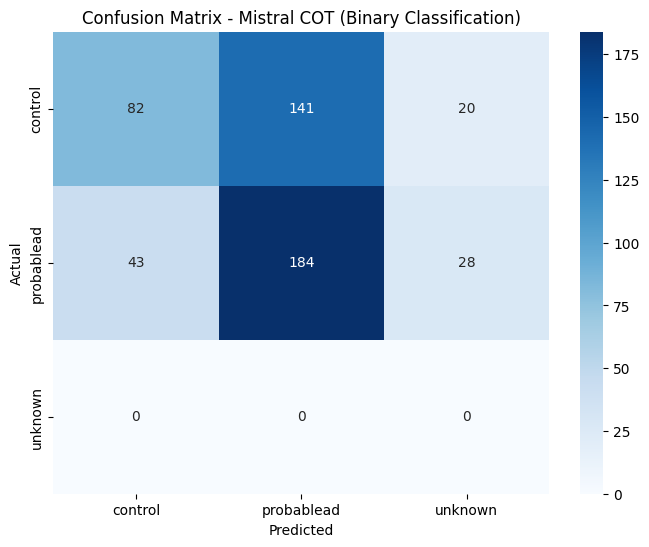

Saved confusion matrix to: D:\Dementia-Thesis - Don't access without permission\mistral_cot_confusion_matrix.png


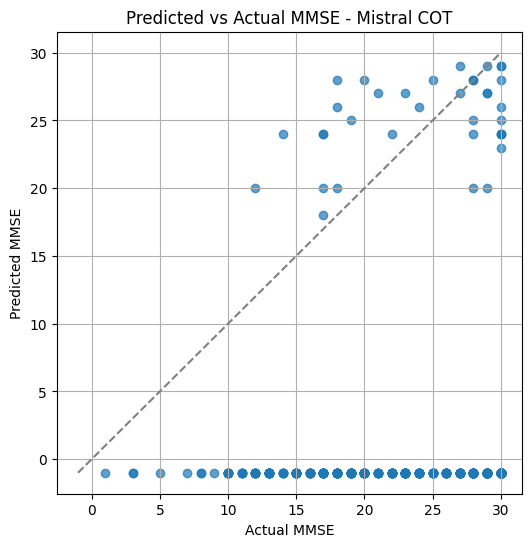

Saved MMSE scatter plot to: D:\Dementia-Thesis - Don't access without permission\mistral_cot_mmse_scatter.png
Saved per-class precision/recall/f1 to: D:\Dementia-Thesis - Don't access without permission\mistral_cot_per_class_prf.csv
Saved eval summary to: D:\Dementia-Thesis - Don't access without permission\mistral_cot_eval_summary.csv


In [4]:
# eval_cot_vs_actual.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# ---------- Paths ----------
actual_path = r"D:\Dementia-Thesis - Don't access without permission\2_classes.csv"
pred_path   = r"D:\Dementia-Thesis - Don't access without permission\Thesis\mistral_cot.csv"

# ---------- Load CSVs ----------
print("Loading CSVs...")
df_true = pd.read_csv(actual_path)
df_pred = pd.read_csv(pred_path)
print("Loaded actual:", actual_path)
print("Loaded predictions:", pred_path)

# ---------- Column mapping ----------
# Actual CSV columns: id, mmse, dx (or similar)
# Prediction CSV columns: id, confidence, mmse, dx

# For actual data - use mmse and dx columns
mmse_true_col = "mmse"
label_true_col = "dx"

# For prediction data - use mmse and dx columns
mmse_pred_col = "mmse"
label_pred_col = "dx"

print(f"Using (actual) mmse column: '{mmse_true_col}'  label column: '{label_true_col}'")
print(f"Using (pred)   mmse column: '{mmse_pred_col}'  label column: '{label_pred_col}'")

# ---------- Rename for consistency ----------
df_true = df_true.rename(columns={mmse_true_col: "actual_mmse", label_true_col: "actual_label"})
df_pred = df_pred.rename(columns={mmse_pred_col: "pred_mmse", label_pred_col: "pred_label"})

# ---------- Ensure 'id' exists in both ----------
if "id" not in df_true.columns or "id" not in df_pred.columns:
    raise KeyError("Both CSVs must contain an 'id' column for matching (patient id).")

# ---------- Merge on id ----------
df_merged = pd.merge(df_pred, df_true, on="id", how="inner", suffixes=("_pred", "_true"))
if df_merged.empty:
    raise ValueError("Merge resulted in 0 rows. Check that 'id' values match between files.")

print(f"Merged {len(df_merged)} rows on 'id'.")

# ---------- Normalize label strings ----------
df_merged["pred_label_norm"] = df_merged["pred_label"].astype(str).str.strip().str.lower()
df_merged["actual_label_norm"] = df_merged["actual_label"].astype(str).str.strip().str.lower()
df_merged["label_match"] = df_merged["pred_label_norm"] == df_merged["actual_label_norm"]

# ---------- Numeric MMSE ----------
df_merged["pred_mmse"] = pd.to_numeric(df_merged["pred_mmse"], errors="coerce")
df_merged["actual_mmse"] = pd.to_numeric(df_merged["actual_mmse"], errors="coerce")
df_merged["mmse_diff"] = (df_merged["pred_mmse"] - df_merged["actual_mmse"]).abs()

# ---------- Metrics ----------
label_accuracy = df_merged["label_match"].mean() * 100
mae = df_merged["mmse_diff"].mean()
corr = df_merged["pred_mmse"].corr(df_merged["actual_mmse"])

# Optional: per-class precision/recall/f1
labels = sorted(set(df_merged["actual_label_norm"].unique()) | set(df_merged["pred_label_norm"].unique()))
y_true = df_merged["actual_label_norm"]
y_pred = df_merged["pred_label_norm"]
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)

prf_df = pd.DataFrame({
    "label": labels,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

# ---------- Print summary ----------
print("\n📊 Evaluation Results (Mistral Chain-of-Thought)")
print(f"Samples evaluated: {len(df_merged)}")
print(f"Label Accuracy: {label_accuracy:.2f}% ({int(df_merged['label_match'].sum())}/{len(df_merged)})")
print(f"MMSE Mean Absolute Error (MAE): {mae:.3f}")
print(f"MMSE Pearson correlation: {corr:.3f}\n")

print("Per-class precision/recall/f1:")
print(prf_df.to_string(index=False))

# ---------- Save merged CSV ----------
out_csv = r"D:\Dementia-Thesis - Don't access without permission\mistral_cot_vs_actual_evaluation.csv"
df_merged.to_csv(out_csv, index=False)
print(f"\nSaved merged evaluation CSV: {out_csv}")

# ---------- Confusion matrix ----------
cm = confusion_matrix(df_merged["actual_label_norm"], df_merged["pred_label_norm"], labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Mistral COT (Binary Classification)")
confusion_path = r"D:\Dementia-Thesis - Don't access without permission\mistral_cot_confusion_matrix.png"
plt.savefig(confusion_path, bbox_inches="tight")
plt.show()
print(f"Saved confusion matrix to: {confusion_path}")

# ---------- Scatter plot: actual vs predicted MMSE ----------
plt.figure(figsize=(6,6))
plt.scatter(df_merged["actual_mmse"], df_merged["pred_mmse"], alpha=0.7)
xmin = min(df_merged["actual_mmse"].min(), df_merged["pred_mmse"].min())
xmax = max(df_merged["actual_mmse"].max(), df_merged["pred_mmse"].max())
plt.plot([xmin, xmax], [xmin, xmax], linestyle="--", color="gray")
plt.xlabel("Actual MMSE")
plt.ylabel("Predicted MMSE")
plt.title("Predicted vs Actual MMSE - Mistral COT")
plt.grid(True)
scatter_path = r"D:\Dementia-Thesis - Don't access without permission\mistral_cot_mmse_scatter.png"
plt.savefig(scatter_path, bbox_inches="tight")
plt.show()
print(f"Saved MMSE scatter plot to: {scatter_path}")

# ---------- Save per-class PRF ----------
prf_out = r"D:\Dementia-Thesis - Don't access without permission\mistral_cot_per_class_prf.csv"
prf_df.to_csv(prf_out, index=False)
print(f"Saved per-class precision/recall/f1 to: {prf_out}")

# ---------- Small summary file ----------
summary = {
    "n_samples": [len(df_merged)],
    "label_accuracy_pct": [label_accuracy],
    "mmse_mae": [mae],
    "mmse_corr": [corr]
}
pd.DataFrame(summary).to_csv(r"D:\Dementia-Thesis - Don't access without permission\mistral_cot_eval_summary.csv", index=False)
print("Saved eval summary to: D:\\Dementia-Thesis - Don't access without permission\\mistral_cot_eval_summary.csv")